# Colerectal Cancer (CRC) Fusion-Gene Analysis
1. Collate the Arriba fusion results for every library, across the 3 datasets
2. Are the same fusions found in all replicates, and in treatment vs control?
3. Comparative genomics: compare fusions bound in human vs vs mouse
4. Compare the fusions detected with bulk RNA-seq (Arriba) and long reads (Sun et al. Table S6)

Arriba is a tool that scans RNA-seq reads and predict these fusions. Each dataset is a folder of .tsv tables: one table per sequenced library/sample

## Preprocessing
Librarires used:
* pandas
* matplotlib
* os
* glob
* re

In [19]:
# Import libraries
import pandas as pd     # dataframes
import matplotlib.pyplot as plt   # plotting
import os               # universal filepaths
import re               # regular expressions
import glob             # files searching
from pathlib import Path    # Type annotations

# Data directories
# Data is stored in folder before repo in <parent>/Data/Arriba results
# os.path.join combines path together with the correct slash/separators for the OS; ".." goes up one folder
# Notebook should be in src/CRC
Data_Dir = os.path.join("..", "..", "..", "Data", "Arriba results")
Suppl_Dir = os.path.join("..", "..", "..", "Data", "Supp_tables_fusion_events.xlsx")
Results_Dir = os.path.join("..", "..", "results")

# Sanity checks
print(f"Arriba data is in: {os.path.abspath(Data_Dir)}\nSupplementary sheet is in: {os.path.abspath(Suppl_Dir)}")
print(f"Arriba data exists?: {os.path.isdir(Data_Dir)}\nSupplementary data exists?: {os.path.isfile(Suppl_Dir)}")


Arriba data is in: /Users/almarcastorga/Documents/5th Year MSc Bioinformatics/Fusion Gene Hackathon/Data/Arriba results
Supplementary sheet is in: /Users/almarcastorga/Documents/5th Year MSc Bioinformatics/Fusion Gene Hackathon/Data/Supp_tables_fusion_events.xlsx
Arriba data exists?: True
Supplementary data exists?: True


### Data tidying functions
- Arriba gene2 column sometimes has two genes inside it e.g. (Gm18582(33168),Gm48918(208887)). This occurs when the breakpoints are between two genes. Decide to drop one or the other and the numbers
- Extract the experiment condition from each sample name

In [20]:
def clean_gene(name: str) -> str:
    """
    Return a clean singular gene ID from Arriba gene2 column
    - regex to remove all bracketed digits
    - .split to only keep the text 
    """
    name = str(name)
    name = re.sub(r"\(\d+\)", "", name)     # remove "(123)"" bracketed numbers
    name = name.split(",")[0]
    return name.strip()

def condition(sample_name:str) -> str:
    """
    Extract the experiment condition from a library/sample
    - IFN_1 = IFN
    - ctrl_2 = ctrl
    - organoid_GC_3 = GCA
    - KRAS_organoids_antiEGFR_1 = antiEGFR
    """
    name = sample_name
    # Remove dataset specific prefixes not part of the condition
    name = name.replace("KRAS_organioids_", "")
    name = name.replace("organoid_", "")
    # Remove replicate number
    name = re.sub(r"_\d+$", "", name)
    return name

## Collate every library/sample onto one
Reading every Arriba .tsv file from all three datasets and stack them. Adding columns stating which dataset, library/sample and condition each fusion came from.

In [ ]:
Datasets = { "mouse_ifn":   "PRJNA1062304_arriba_mouse_ifn",
            "human_bile":   "PRJNA1269539_arriba_human_bile_salts",
            "human_antiEGFR":   "PRJNA1462607_arriba_human_antiEGFR"}

def load_library(tsv_path: Path, dataset: str) -> pd.DataFrame:
    """
    Read one Arriba .tsv file into a DF and add label columns
    """
    df = pd.read_csv(tsv_path, sep="\t")
    df = df.rename(columns={"#gene1": "gene1"}) # clean column

    # get clean library/sample name 
    library = os.path.basename(tsv_path).replace(".fusions.tsv","")

    # Add label columns to know where each row came from
    df.insert(0, "library", library)
    df.insert(0, "dataset", dataset)
    df["condition"] = condition(library)

    # Build tidy gene ids and single fusion pair id
    df["gene1_clean"] = df["gene1"].apply(clean_gene)
    df["gene2_clean"] = df["gene2"].apply(clean_gene)
    df["fusion_pair"] = df["gene1_clean"] + "::" + df["gene2_clean"]

    return df

# Loop for every dataset folder and every .tsv file
all_df = []
for name, folder in Datasets.items():
    pattern = os.path.join(Data_Dir, folder, "*.fusions.tsv")   # match all tsv files
    for tsv_file in sorted(glob.glob(pattern)):     # sorted() = predictable order
        all_df.append(load_library(tsv_file, name))

# stacks all the tables onto one
fusions = pd.concat(all_df, ignore_index= True)

print("Collated", len(fusions), "fusion rows from", fusions["library"].nunique(), "libraries.")
fusions.head()  # sanity check


Collated 1418 fusion rows from 24 libraries.


,dataset,library,gene1,gene2,strand1(gene/fusion),strand2(gene/fusion),breakpoint1,breakpoint2,site1,site2,...,direction1,direction2,filters,fusion_transcript,peptide_sequence,read_identifiers,condition,gene1_clean,gene2_clean,fusion_pair
0,mouse_ifn,IFN_1,C730002L08Rik,Anxa1,-/-,-/-,19:20434346,19:20361215,intron,CDS/splice-site,...,upstream,downstream,"duplicates(39),mismatches(8)",AATGTCCTTGATAATAAATGGTATGGCCCGGATCCTATTTTGATAA...,.,"SRR27464946.102223,SRR27464946.10223525,SRR274...",IFN,C730002L08Rik,Anxa1,C730002L08Rik::Anxa1
1,mouse_ifn,IFN_1,"1700024G13Rik(4878),Chat(14934)",Baiap2l1,./-,-/-,14:32115226,5:144223120,intergenic,CDS/splice-site,...,upstream,downstream,"duplicates(78),inconsistently_clipped(2),misma...",TCTTGCTCTCTTGCTTCCTGCACCCTGGCTCCTGAAGATGTAAGAA...,.,"SRR27464946.11999621,SRR27464946.13255452,SRR2...",IFN,1700024G13Rik,Baiap2l1,1700024G13Rik::Baiap2l1
2,mouse_ifn,IFN_1,Gm73738,Slc1a2,+/+,+/+,7:116936505,2:102566289,exon/splice-site,CDS/splice-site,...,downstream,upstream,"duplicates(25),mismatches(8),multimappers(31)",ACGCGTCTAATAACAATTGGTGCCGAATTCCGGGACGAGAAAAAAC...,.,"SRR27464946.10262611,SRR27464946.10262859,SRR2...",IFN,Gm73738,Slc1a2,Gm73738::Slc1a2
3,mouse_ifn,IFN_1,Reep5,Pkd2l2,-/-,+/-,18:34490145,18:34561328,CDS/splice-site,intron,...,upstream,downstream,duplicates(14),CGGACTGGTGGCTTTGTATCTGGTGTTCGGTTATGGAGCCTCTCTC...,GLVALYLVFGYGASLLCNLIGFGYPAYISMKAIESPNKDDDTQWLT...,"SRR27464946.11220796,SRR27464946.11221706,SRR2...",IFN,Reep5,Pkd2l2,Reep5::Pkd2l2
4,mouse_ifn,IFN_1,Mmd,Efcab2,+/+,+/-,11:90148427,1:178299867,CDS/splice-site,intron,...,downstream,downstream,"duplicates(12),low_entropy(1),mismatches(5)",CCCCGGTGTGGCCCACTCCGGCCCTGCCCAGTTGCGTGGCTCCCGC...,MRFRNRFQRFMNHRAPANGRYKPTCYEHAANCYTHA|qqqwitgiw...,"SRR27464946.13967596,SRR27464946.14198276,SRR2...",IFN,Mmd,Efcab2,Mmd::Efcab2


In [22]:
# Count how many fusion rows each library has
per_library = (
    fusions.groupby(["dataset", "library"])
           .size()  # count rows in each group
           .reset_index(name="n_fusions")   # turn the result back into a table
)
per_library

,dataset,library,n_fusions
0,human_antiEGFR,KRAS_organoids_antiEGFR_1,30
1,human_antiEGFR,KRAS_organoids_antiEGFR_2,30
2,human_antiEGFR,KRAS_organoids_antiEGFR_3,21
3,human_antiEGFR,KRAS_organoids_ctrl_1,30
4,human_antiEGFR,KRAS_organoids_ctrl_2,23
5,human_antiEGFR,KRAS_organoids_ctrl_3,43
6,human_bile,organoid_CA_1,17
7,human_bile,organoid_CA_2,17
8,human_bile,organoid_CA_3,23
9,human_bile,organoid_GCA_1,33


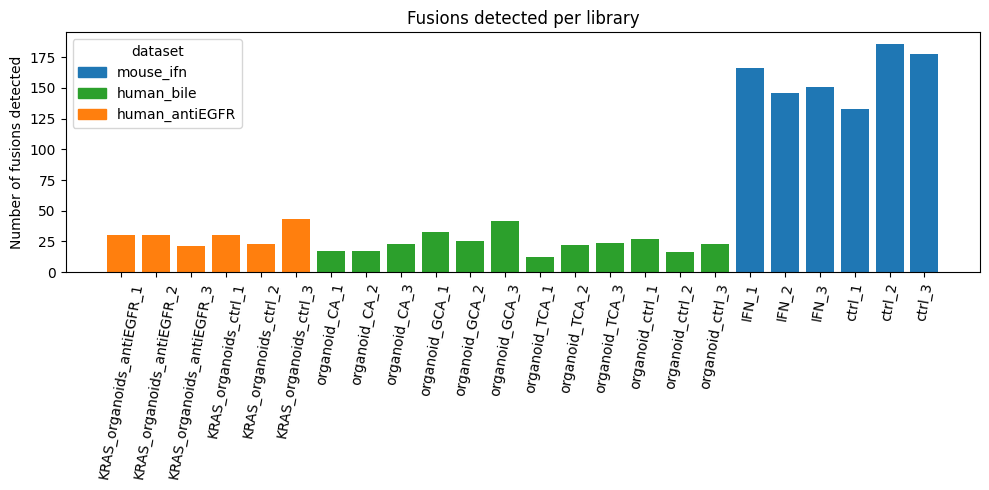

In [27]:
#bar chart of fusions per library, coloured by dataset.
fig, ax = plt.subplots(figsize=(10, 5))

# Give each dataset its own colour.
colours = {"mouse_ifn": "tab:blue", "human_bile": "tab:green", "human_antiEGFR": "tab:orange"}
bar_colours = [colours[dataset] for dataset in per_library["dataset"]]

ax.bar(per_library["library"], per_library["n_fusions"], color=bar_colours)
ax.set_ylabel("Number of fusions detected")
ax.set_title("Fusions detected per library")
plt.xticks(rotation=80)
plt.tight_layout()

# Build legend (one coloured square per dataset).
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=d) for d, c in colours.items()]
ax.legend(handles=handles, title="dataset")

plt.savefig(os.path.join(Results_Dir, "fusions_per_library.png"), dpi=150)
plt.show()
